# Swizzle

[lds_bank_conflicts](https://rocm.docs.amd.com/projects/composable_kernel/en/latest/conceptual/ck_tile/hardware/lds_bank_conflicts.html) shows that:

 - MI300 has 32 x 32bits banks, usine DW4/128b access, can be viewed as 8 x 128bits banks.
 - LDS HW can only serve 8 x 128b accesses at the same time, and there will no conflict if these 8 accesses fall into different banks.
 - Thus 64 128b-aceeses from one wave are split into 8 groups (with 8 accesses per group served concurrently by LDS):
   - ds_write_b128: group is 0:7, 8:15, 16:23, 24:31, 32:39, 40:47, 48:55, 56:63
   - ds_read_b128: group is 0:3+20:23, 4:7+16:19, 8:11+28:31, 12:15+24:27, 32:35+52:55, 36:39+48:51, 40:43+60:63, 44:47+56:59


# UseCase: LDS used as MFMA A/B buffer

In 2D gemm problem, LDS is used as A/B block ping-pong buffer, holding (Block_M, Block_K) data elements.
  - due to HBM-coalescing requirement,  data read from HBM row-by-row, thus lds-write happens row by row
  - due to MFMA A/B layout requirement, lds-reads happens in unit of A/B layout (16, 4) x 128b, with lane-groups highlighted in different colors

![ds_read_b128 lane-groups](./b128_lane_groups.png)

Further assume Block_K is integer multiple of 32-banks width (8x128b, 16x64b, 32xfp32, 64xbf16 or 128xfp8).

In following example, each lane is a 128b width, and we can see in Block_K direction, each two (16,4)_128b blocks covers a banks, and the pattern repeats integer multiple times.

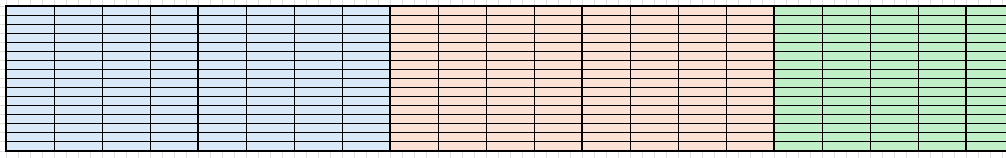

and we can show that swizzle in unit of 128b is simply done by `(k^m)`.
   - here `m` is row number, but it can also be any number which increases with row number, for example `(linear_offset >> 3)` with `linear_offset=m*Block_K + k` since Block_K is integer multiple of 8
   - here `k` is col number within two (16,4)_128b blocks, which is 3 least-significant bits of `linear_offset`
   - here the element is 128b which is 8 x bf16, 3-bits address within this unit is unchanged.

In language of [cutlass](https://docs.nvidia.com/cutlass/latest/media/docs/pythonDSL/cute_dsl_api/cute.html#cutlass.cute.Swizzle), it's a (3,3,3) swizzle.


In [2]:
for m in range(8):
    line = ['______'] * 8
    for k in range(4):
        k1 = (k ^ m)
        lane = m + k*16
        line[k1] = f"lane{lane:2d}"
    print("|".join(line))

lane 0|lane16|lane32|lane48|______|______|______|______
lane17|lane 1|lane49|lane33|______|______|______|______
lane34|lane50|lane 2|lane18|______|______|______|______
lane51|lane35|lane19|lane 3|______|______|______|______
______|______|______|______|lane 4|lane20|lane36|lane52
______|______|______|______|lane21|lane 5|lane53|lane37
______|______|______|______|lane38|lane54|lane 6|lane22
______|______|______|______|lane55|lane39|lane23|lane 7


we can see swizzle:
 - switch every 2 column in odd rows
 - switch every 2 pair-of-columns in odd (rows//2)
 - switch every 2 four-columns in odd (rows//4), and this avoids conflicts in lane-groups of ds_read_b128.


This swizzle also works when we exchange 128b ds_write & ds_read, for example when we write in MFMA A/B layout and read in mem-coalescing layout (the Cshuffle)